<a href="https://colab.research.google.com/github/xavya-dev/OpenSearch/blob/main/PrimeTrade_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

# Load datasets
try:
    # Update these filenames to match exactly what you uploaded
    trader_df = pd.read_csv('historical_data.csv')
    sentiment_df = pd.read_csv('fear_greed_index.csv') # File name change madi check madi

    print("✅ Files loaded successfully!\n")

    print("--- Trader Data (First 3 Rows) ---")
    print(trader_df.head(3))

    print("\n--- Sentiment Data (First 3 Rows) ---")
    print(sentiment_df.head(3))

except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("Please check if the file names match exactly with the uploaded files in the left panel.")

✅ Files loaded successfully!

--- Trader Data (First 3 Rows) ---
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
1         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
2         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   

   Crossed  

In [6]:
# 1. Trader data date conversion with format fix
try:
    # 'dayfirst=True' mattu 'format="mixed"' add madiddivi
    trader_df['Date'] = pd.to_datetime(trader_df['Timestamp IST'], format='mixed', dayfirst=True).dt.date
except KeyError:
    trader_df['Date'] = pd.to_datetime(trader_df['time'], format='mixed', dayfirst=True).dt.date

# 2. Sentiment data date conversion with format fix
try:
    sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date'], format='mixed', dayfirst=True).dt.date
except KeyError:
    sentiment_df['Date'] = pd.to_datetime(sentiment_df['date'], format='mixed', dayfirst=True).dt.date

# 3. Eradu dataset na 'Date' base mele MERGE madona
merged_df = pd.merge(trader_df, sentiment_df, on='Date', how='left')

print("✅ Data Merge Success!")
print("\n--- Merged Data First 3 Rows ---")
print(merged_df.head(3))

✅ Data Merge Success!

--- Merged Data First 3 Rows ---
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  52017706630     True  0.345404  8.950000e+14   
1         0.0  ...  52017706630     True  0.005600  4.430000e+14   
2         0.0  ...  52017706630     True  0.050431  6.600000e+14   

      Timestamp        Date     timestamp  value  classification        d

In [3]:
import pandas as pd

# 1. Load the data
trader_df = pd.read_csv('historical_data.csv')
sentiment_df = pd.read_csv('fear_greed_index.csv')

# 2. Fix the date format and extract Date
try:
    trader_df['Date'] = pd.to_datetime(trader_df['Timestamp IST'], format='mixed', dayfirst=True).dt.date
except KeyError:
    trader_df['Date'] = pd.to_datetime(trader_df['time'], format='mixed', dayfirst=True).dt.date

try:
    sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date'], format='mixed', dayfirst=True).dt.date
except KeyError:
    sentiment_df['Date'] = pd.to_datetime(sentiment_df['date'], format='mixed', dayfirst=True).dt.date

# 3. Merge both datasets
merged_df = pd.merge(trader_df, sentiment_df, on='Date', how='left')

# 4. Print the column names to find the exact name for 'Classification'
print("✅ Data Loaded and Merged Successfully!")
print("\n--- Column Names in Merged Data ---")
print(merged_df.columns.tolist())

✅ Data Loaded and Merged Successfully!

--- Column Names in Merged Data ---
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Date', 'timestamp', 'value', 'classification', 'date']


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Market Sentiment mele Average Profit/Loss (PnL) check madona
print("--- Average Profit/Loss (PnL) by Market Sentiment ---")
pnl_by_sentiment = merged_df.groupby('classification')['Closed PnL'].mean()
print(pnl_by_sentiment)

# 2. Win Rate Calculate madona (Profit aada trades percentage yeshtu?)
# Profit 0 ginta jasti idre True (Win), illandre False (Loss)
merged_df['is_win'] = merged_df['Closed PnL'] > 0
win_rate = merged_df.groupby('classification')['is_win'].mean() * 100

print("\n--- Win Rate (%) by Market Sentiment ---")
print(win_rate)

# 3. Sentiment ge thakkange trade size (amount) hege change aagutte?
print("\n--- Average Trade Size (USD) by Market Sentiment ---")
size_by_sentiment = merged_df.groupby('classification')['Size USD'].mean()
print(size_by_sentiment)

--- Average Profit/Loss (PnL) by Market Sentiment ---
classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

--- Win Rate (%) by Market Sentiment ---
classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: is_win, dtype: float64

--- Average Trade Size (USD) by Market Sentiment ---
classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


/tmp/ipykernel_4782/2726098135.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pnl_by_sentiment.index, y=pnl_by_sentiment.values, palette='viridis')
/tmp/ipykernel_4782/2726098135.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_rate.index, y=win_rate.values, palette='coolwarm')


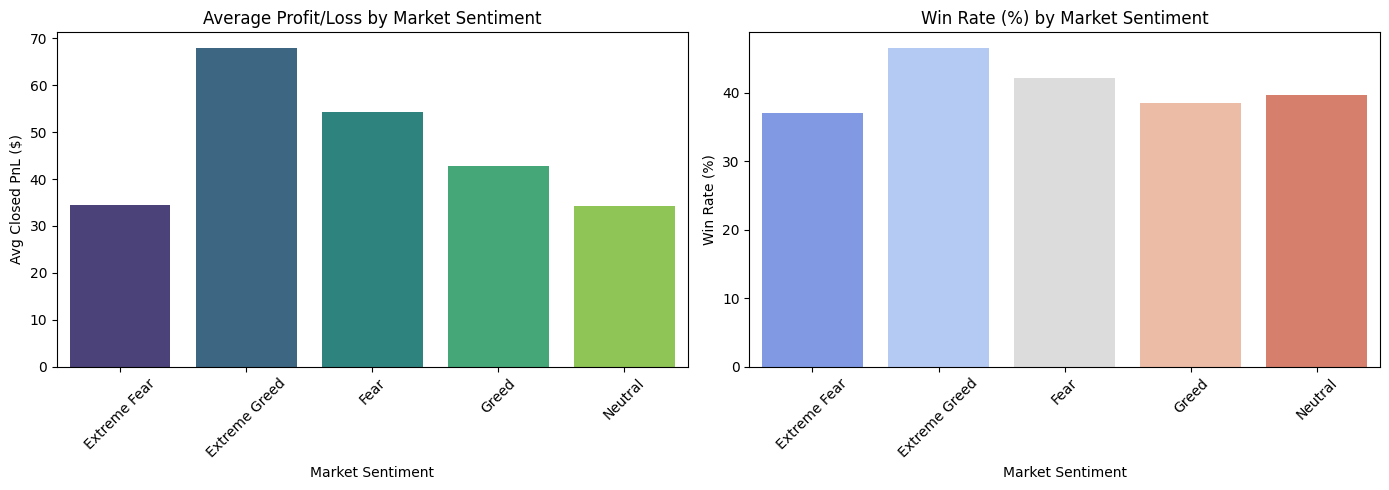

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graph ge size set madona
plt.figure(figsize=(14, 5))

# 1. Average Profit/Loss Graph
plt.subplot(1, 2, 1)
sns.barplot(x=pnl_by_sentiment.index, y=pnl_by_sentiment.values, palette='viridis')
plt.title('Average Profit/Loss by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Avg Closed PnL ($)')
plt.xticks(rotation=45)

# 2. Win Rate Graph
plt.subplot(1, 2, 2)
sns.barplot(x=win_rate.index, y=win_rate.values, palette='coolwarm')
plt.title('Win Rate (%) by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()